# 🏠 House Price Prediction using Linear Regression

## Artificial Intelligence & Machine Learning – Task 1

**Name:** Parth Panchal  
**Course:** Bachelor of Engineering (Information Technology)  
**University:** Gujarat Technological University (GTU)  
**Dataset:** California Housing Dataset  
**Algorithm:** Linear Regression

## Step 1: Import Required Libraries

In this step, all the required Python libraries are imported. These libraries help in data handling, visualization, machine learning model development, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

The California Housing dataset is loaded using Scikit-learn. It contains information about different districts in California and their corresponding house prices.

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["HousePrice"] = housing.target

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset. This includes checking the number of rows and columns, data types, missing values, and viewing sample records.

In [3]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display first 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Display last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Last 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


## Step 4: Data Cleaning and Statistical Analysis

The dataset is checked for missing values and statistical information such as mean, minimum, maximum, and standard deviation is displayed.

In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 5: Data Visualization

Graphs are created to understand the distribution of data and the relationship between different features. Visualization helps in identifying important patterns.

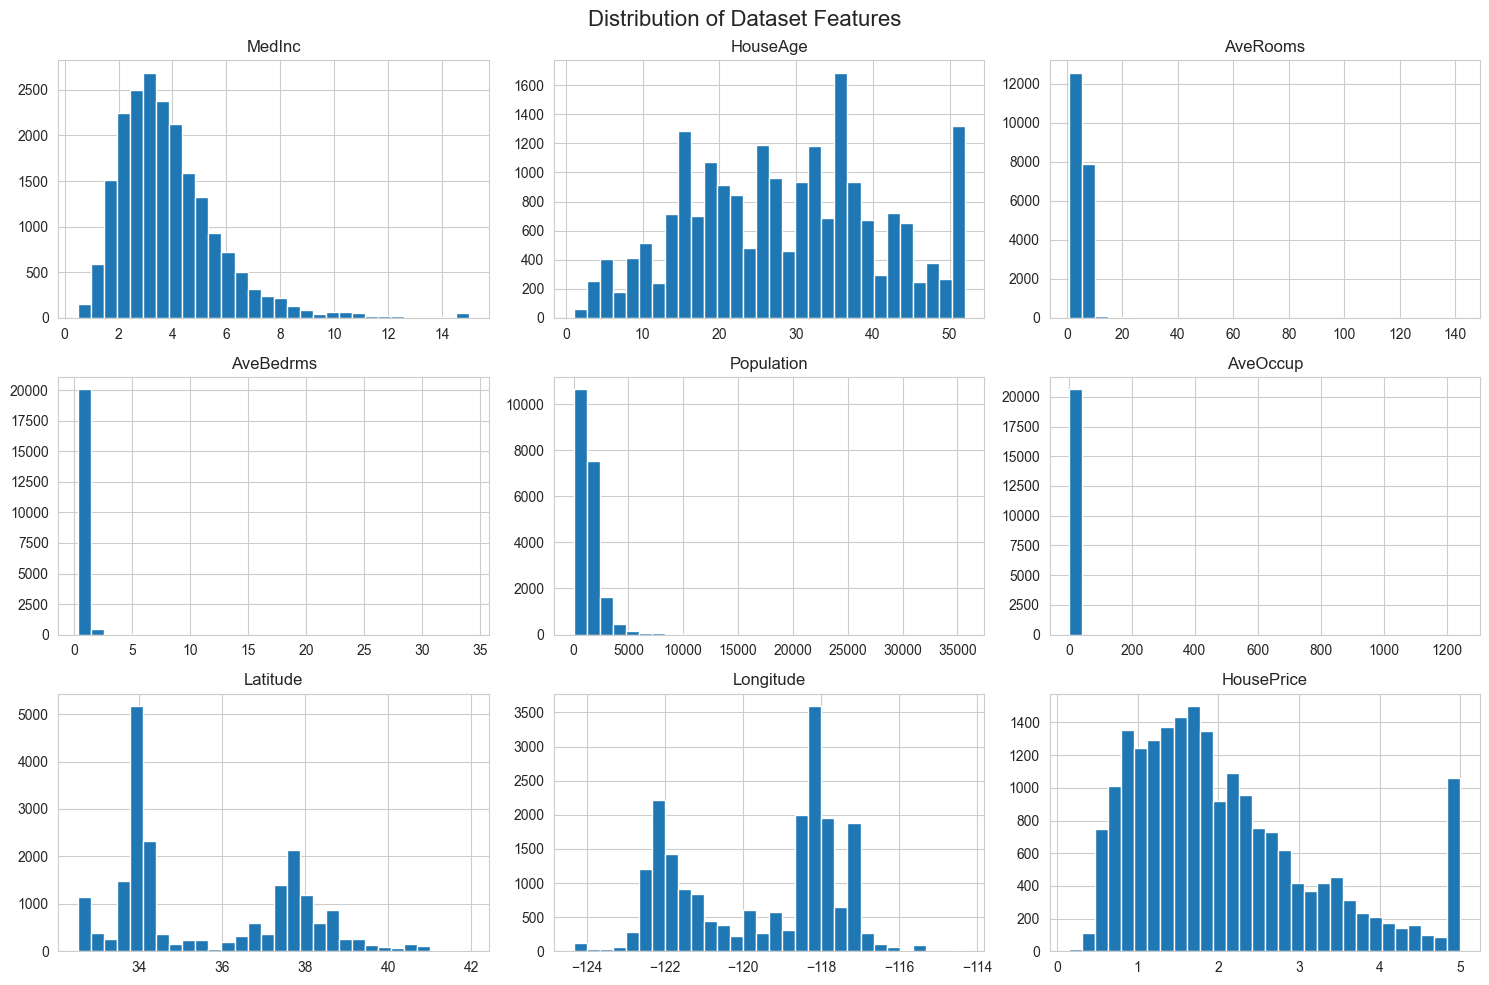

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set graph style
sns.set_style("whitegrid")

# Plot histogram for all numerical features
df.hist(figsize=(15,10), bins=30)

plt.suptitle("Distribution of Dataset Features", fontsize=16)
plt.tight_layout()

plt.show()

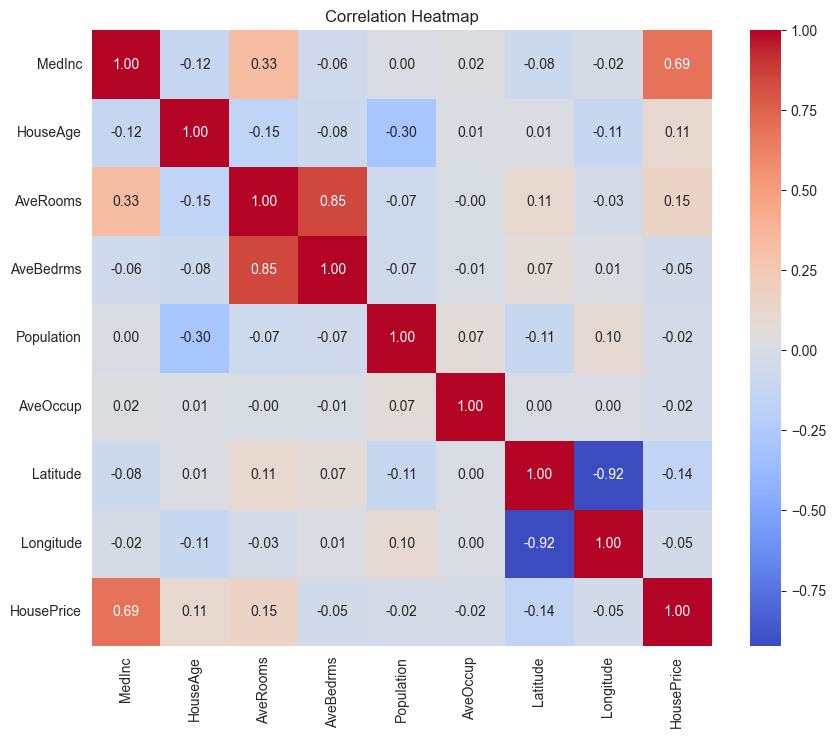

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

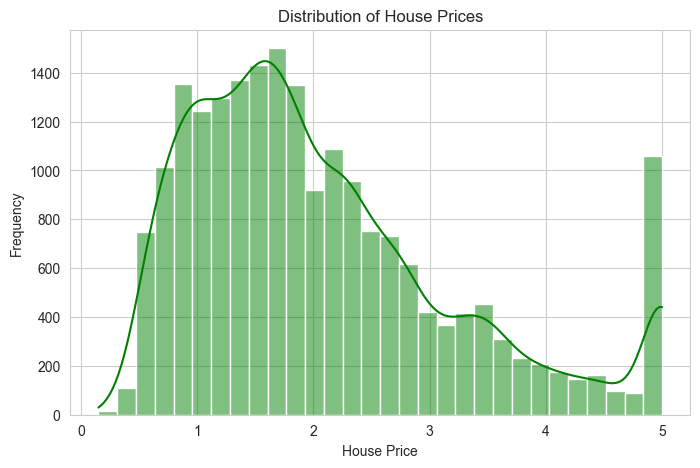

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["HousePrice"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

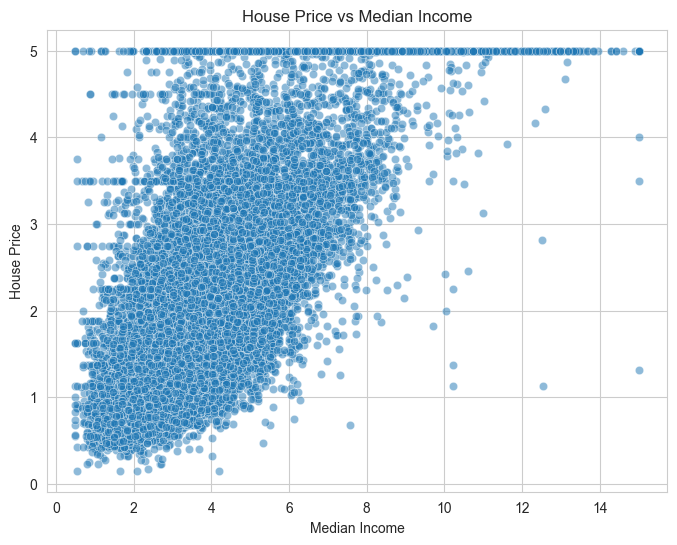

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["MedInc"],
    y=df["HousePrice"],
    alpha=0.5
)

plt.title("House Price vs Median Income")
plt.xlabel("Median Income")
plt.ylabel("House Price")

plt.show()

## Step 6: Feature Selection

The input features (X) and target variable (HousePrice) are separated before training the machine learning model.

In [9]:
# Features (Input)
X = df.drop("HousePrice", axis=1)

# Target (Output)
y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Display first 5 rows of features
display(X.head())

# Display first 5 target values
display(y.head())

Features Shape: (20640, 8)
Target Shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HousePrice, dtype: float64

## Step 7: Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


## Step 8: Model Training

A Linear Regression model is created and trained using the training dataset. The model learns the relationship between the input features and the target variable.

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


## Step 9: Prediction

The trained model predicts house prices using the testing dataset. These predicted values are compared with the actual house prices.

In [12]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

prediction_df.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Step 10: Model Evaluation

The performance of the model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [13]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Print the results
print("Model Evaluation Results")
print("-" * 35)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Model Evaluation Results
-----------------------------------
Mean Absolute Error (MAE) : 0.5332
Mean Squared Error (MSE)  : 0.5559
Root Mean Squared Error (RMSE) : 0.7456
R² Score : 0.5758


## Step 11: Result Visualization

A scatter plot is created to compare the actual house prices with the predicted house prices. Points closer to the reference line indicate better prediction accuracy.

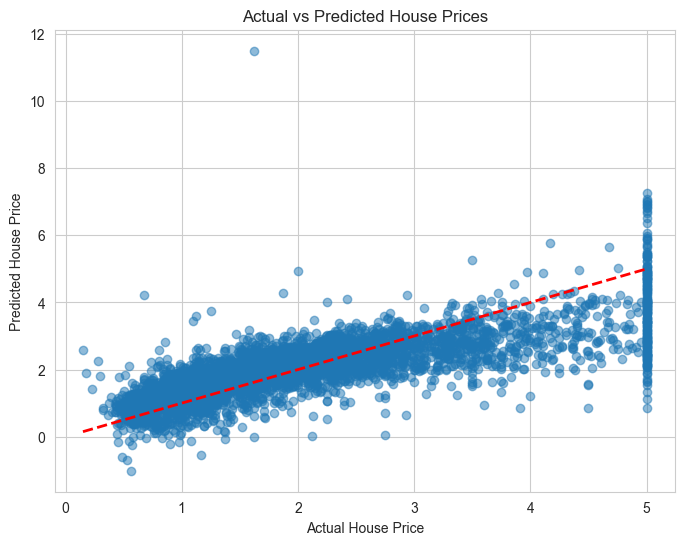

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

## Step 12: Feature Coefficients

The coefficients of the Linear Regression model are displayed to understand the influence of each feature on house price prediction.

In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


## Step 13: Save the Model

The trained model is saved as a `.pkl` file using the Joblib library so that it can be reused without retraining.

In [16]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

In this project, a Linear Regression model was successfully developed to predict house prices using the California Housing dataset.

The dataset was explored through Exploratory Data Analysis (EDA), visualized using different graphs, and prepared for machine learning by separating the features and target variable.

The dataset was divided into training and testing sets, after which the Linear Regression model was trained successfully. The model's performance was evaluated using MAE, MSE, RMSE, and R² Score.

The results demonstrate that Linear Regression can effectively predict house prices based on the available features. Although the model performs reasonably well, prediction accuracy can be further improved by using more advanced machine learning algorithms such as Random Forest, Decision Tree, or XGBoost.